<a href="https://colab.research.google.com/github/Rehman-Cg7/AIML/blob/main/Week2_Last_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Dataset load karo
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [3]:
# Features jo humein lagta hai price affect karte hain
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']

X = df[features]
y = df['MedHouseVal']

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms
0,8.3252,41.0,6.984127,1.023810
1,8.3014,21.0,6.238137,0.971880
2,7.2574,52.0,8.288136,1.073446
3,5.6431,52.0,5.817352,1.073059
4,3.8462,52.0,6.281853,1.081081


Train-Test `Split`



I selected these four features:
MedInc (Median Income): Areas with higher median income generally have more expensive houses.
HouseAge: The age of a house can affect its value.
AveRooms: Houses with more rooms are generally larger and may have higher prices.
AveBedrms: The number of bedrooms is also related to the size and price of a house.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16512, 4)
Testing size: (4128, 4)


# Linear Regression Model Training

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

# Pehli 5 predictions dekho
print("Predicted:", y_pred[:5])
print("Actual:", y_test[:5].values)

Predicted: [1.01104548 1.55515054 2.6560014  2.64922673 1.98424794]
Actual: [0.477   0.458   5.00001 2.186   2.78   ]



# Model Evaluation — RMSE Aur R²

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.8022
R² Score: 0.5089


# Scatter Plot — Predicted vs Actual

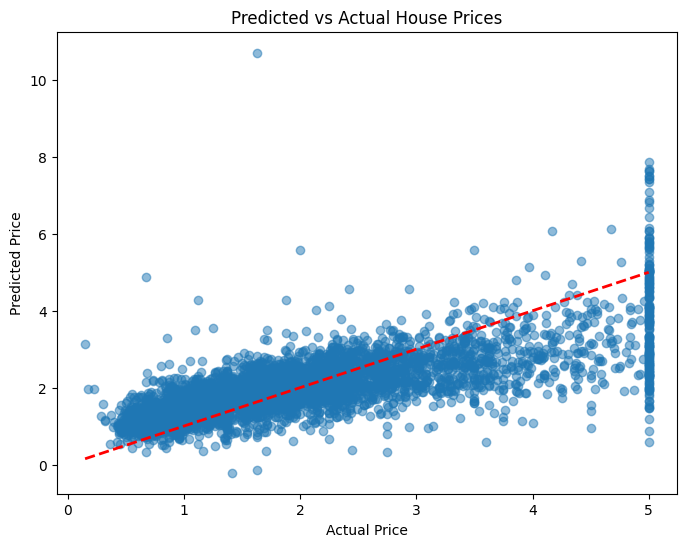

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual House Prices')
plt.show()

How to read this chart: Each dot represents a house. The X-axis shows the actual price, while the Y-axis shows the model’s predicted price. The red dashed line represents the perfect prediction line—if the model were perfect, all the dots would lie exactly on this line. The closer the dots are to the line, the better the model’s predictions. If the dots are widely scattered, it indicates that the model has a higher prediction error.

R² Score Explanation (Non-Technical)
My model’s R² score is 0.5089, which means that the model explains about 50.89% of the variation in house prices using these four features: income, age, rooms, and bedrooms.

In simple terms, if we provide the model with information about a house’s income level, age, and number of rooms and bedrooms, it can explain around 50.89% of the variation in its price. The remaining 49.11% is influenced by other factors that are not included in our model, such as the exact location, school quality, crime rate, and other housing-related factors.

# RMSE: 0.8022
R² Score: 0.5089